In [3]:

import os
import matplotlib.pyplot as plt
import pandas as pd
import json
result_root_path = "../data/results"
result_models = {
    "LSTM": {
        "folder_path": result_root_path + "/Seq2Seq_LSTM",
        "training_time": json.load(open(os.path.join(result_root_path + "/Seq2Seq_LSTM", "training_time.json"), "r"))["train_time_sec"]
    },
   "LSTM_BI": {
       "folder_path": result_root_path + "/Seq2Seq_LSTM_Bidirectional",
       "training_time": json.load(open(os.path.join(result_root_path + "/Seq2Seq_LSTM_Bidirectional", "training_time.json"), "r"))["train_time_sec"]
   },
   "TCN": {
       "folder_path": result_root_path + "/Seq2Seq_TCN",
       "training_time": json.load(open(os.path.join(result_root_path + "/Seq2Seq_TCN", "training_time.json"), "r"))["train_time_sec"]
   },
   "TCN_BI": {
       "folder_path": result_root_path + "/Seq2Seq_TCN_Bidirectional",
       "training_time": json.load(open(os.path.join(result_root_path + "/Seq2Seq_TCN_Bidirectional", "training_time.json"), "r"))["train_time_sec"]    
   }
}
period_info = json.load(open(os.path.join("../data/", "complete_periods_summary.json"), "r"))

In [4]:
%%script false
metrics = ["mse", "mae", "r2", "rmse"]
def plot_results(model_name, folder_path, metric):
    plt.figure(figsize=(15, 10))
    rolling_results = pd.read_csv(os.path.join(folder_path, "rolling_results.csv"))
    rolling_results["period_start"] = [pd.to_datetime(period_info[(period)]["start"]) for period in rolling_results["period"]]
    prediction_results = pd.read_csv(os.path.join(folder_path, "prediction_results.csv"))
    prediction_results["window_start"] = pd.to_datetime(prediction_results["window_start"])
    prediction_results["window_month"] = prediction_results["window_start"].dt.to_period('M')
    #prediction_results = prediction_results.set_index("window_start")

    #prediction_per_month = prediction_results.groupby("window_month").mean()

    plt.subplot(2, 1, 1)
    plt.bar(prediction_results["window_start"], prediction_results[metric] , width=1.5, label=metric)
    plt.title(f"Resultados de Previsão - {model_name}")
    plt.xlabel("Número de Previsão")
    plt.ylabel("Valor")
    plt.legend(loc="upper right")
    plt.grid()

    plt.subplot(2, 1, 2)
    plt.bar(rolling_results["period_start"], rolling_results[metric] , width=2, label=metric)
    plt.title(f"Resultados Rolling - {model_name}")
    plt.xlabel("Período")
    plt.ylabel("Valor")
    plt.xticks(rotation=45, ha='right')
    plt.legend(loc="upper right")
    plt.grid()

    plt.show()

for model_name, model_info in result_models.items():
    for metric in metrics:
        plot_results(model_name, model_info["folder_path"], metric)

CalledProcessError: Command 'b'metrics = ["mse", "mae", "r2", "rmse"]\ndef plot_results(model_name, folder_path, metric):\n    plt.figure(figsize=(15, 10))\n    rolling_results = pd.read_csv(os.path.join(folder_path, "rolling_results.csv"))\n    rolling_results["period_start"] = [pd.to_datetime(period_info[(period)]["start"]) for period in rolling_results["period"]]\n    prediction_results = pd.read_csv(os.path.join(folder_path, "prediction_results.csv"))\n    prediction_results["window_start"] = pd.to_datetime(prediction_results["window_start"])\n    prediction_results["window_month"] = prediction_results["window_start"].dt.to_period(\'M\')\n    #prediction_results = prediction_results.set_index("window_start")\n\n    #prediction_per_month = prediction_results.groupby("window_month").mean()\n\n    plt.subplot(2, 1, 1)\n    plt.bar(prediction_results["window_start"], prediction_results[metric] , width=1.5, label=metric)\n    plt.title(f"Resultados de Previs\xc3\xa3o - {model_name}")\n 

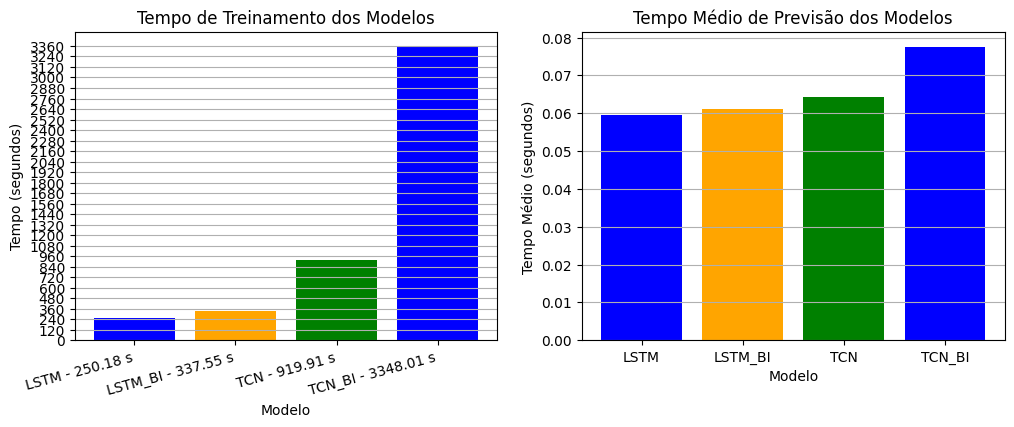

In [5]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
model_names = [(model_name + " - " + f"{model_info['training_time']:.2f} s") for model_name, model_info in result_models.items()]
training_times = [model_info["training_time"] for model_info in result_models.values()]
plt.bar(model_names, training_times, color=['blue', 'orange', 'green'])
plt.title("Tempo de Treinamento dos Modelos")
plt.xlabel("Modelo")
plt.ylabel("Tempo (segundos)")
plt.yticks(range(0, int(max(training_times))+60, 120))  # Ajusta os ticks do eixo y
plt.xticks(rotation=15, ha='right')  # Rotaciona os rótulos do eixo x para melhor visualização
plt.grid(axis='y')

plt.subplot(1, 2, 2)
prediction_times = []
for model_info in result_models.values():
    prediction_results = pd.read_csv(os.path.join(model_info["folder_path"], "prediction_results.csv"))
    prediction_times.append(prediction_results["prediction_time_sec"].mean())
model_names = [model_name for model_name, model_info in result_models.items()]
plt.bar(model_names, prediction_times, color=['blue', 'orange', 'green'])
plt.title("Tempo Médio de Previsão dos Modelos")
plt.xlabel("Modelo")
plt.ylabel("Tempo Médio (segundos)")
plt.grid(axis='y')

plt.show()

In [6]:
def return_metrics(model_name, folder_path):
    rolling_results = pd.read_csv(os.path.join(folder_path, "rolling_results.csv"))
    prediction_results = pd.read_csv(os.path.join(folder_path, "prediction_results.csv"))

    metrics = {
        "model_name": model_name,
        "rolling_mae": rolling_results["mae"].mean(),
        "rolling_mse": rolling_results["mse"].mean(),
        "rolling_rmse": rolling_results["rmse"].mean(),
        "rolling_r2": rolling_results["r2"].mean(),
        "prediction_mae": prediction_results["mae"].mean(),
        "prediction_mse": prediction_results["mse"].mean(),
        "prediction_rmse": prediction_results["rmse"].mean(),
        "prediction_r2": prediction_results["r2"].mean(),
        "average_prediction_time_sec": prediction_results["prediction_time_sec"].mean()
    }

    return metrics

results_df = pd.DataFrame([return_metrics(model_name, model_info["folder_path"]) for model_name, model_info in result_models.items()])
results_df = results_df.sort_values(by="rolling_mae").reset_index(drop=True)
rolling_df = results_df[["model_name", "rolling_mae", "rolling_mse", "rolling_rmse", "rolling_r2", "average_prediction_time_sec"]]
prediction_df = results_df[["model_name", "prediction_mae", "prediction_mse", "prediction_rmse", "prediction_r2", "average_prediction_time_sec"]]

rolling_df = rolling_df.rename(columns={
    "model_name": "Modelo",
    "rolling_mae": "MAE",
    "rolling_mse": "MSE",
    "rolling_rmse": "RMSE",
    "rolling_r2": "R2",
    "average_prediction_time_sec": "Tempo Médio de Previsão (s)"
})
prediction_df = prediction_df.rename(columns={
    "model_name": "Modelo",
    "prediction_mae": "MAE",
    "prediction_mse": "MSE",
    "prediction_rmse": "RMSE",
    "prediction_r2": "R2",
    "average_prediction_time_sec": "Tempo Médio de Previsão (s)"
})

display(rolling_df)
display(prediction_df)

,Modelo,MAE,MSE,RMSE,R2,Tempo Médio de Previsão (s)
0,LSTM_BI,1.655486,4.460687,2.045366,-1.997591,0.061226
1,LSTM,1.679155,4.588149,2.072264,-2.234049,0.059524
2,TCN,1.718890,4.720320,2.106258,-2.284794,0.064220
3,TCN_BI,1.962166,7.781175,2.451645,-5.485308,0.077531


,Modelo,MAE,MSE,RMSE,R2,Tempo Médio de Previsão (s)
0,LSTM_BI,1.223803,2.741134,1.434261,-2.049727,0.061226
1,LSTM,1.229436,2.781738,1.441222,-2.088534,0.059524
2,TCN,1.250167,2.812422,1.459644,-2.308430,0.064220
3,TCN_BI,1.406821,3.518008,1.613940,-3.679504,0.077531


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")


def load_result_frames(model_name, folder_path):
    rolling_results = pd.read_csv(os.path.join(folder_path, "rolling_results.csv"))
    prediction_results = pd.read_csv(os.path.join(folder_path, "prediction_results.csv"))

    rolling_results["model_name"] = model_name
    prediction_results["model_name"] = model_name
    prediction_results["window_start"] = pd.to_datetime(prediction_results["window_start"])
    prediction_results["window_month"] = prediction_results["window_start"].dt.to_period("M")
    prediction_results["window_year"] = prediction_results["window_start"].dt.year
    prediction_results["window_month_num"] = prediction_results["window_start"].dt.month
    return rolling_results, prediction_results


rolling_frames = []
prediction_frames = []
for model_name, model_info in result_models.items():
    rolling_frame, prediction_frame = load_result_frames(model_name, model_info["folder_path"])
    rolling_frames.append(rolling_frame)
    prediction_frames.append(prediction_frame)

rolling_all = pd.concat(rolling_frames, ignore_index=True)
prediction_all = pd.concat(prediction_frames, ignore_index=True)

results_df = pd.DataFrame([
    {
        "model_name": model_name,
        "training_time_sec": model_info["training_time"],
        "rolling_mae": rolling_frame["mae"].mean(),
        "rolling_mse": rolling_frame["mse"].mean(),
        "rolling_rmse": rolling_frame["rmse"].mean(),
        "rolling_r2": rolling_frame["r2"].mean(),
        "prediction_mae": prediction_frame["mae"].mean(),
        "prediction_mse": prediction_frame["mse"].mean(),
        "prediction_rmse": prediction_frame["rmse"].mean(),
        "prediction_r2": prediction_frame["r2"].mean(),
        "prediction_time_sec": prediction_frame["prediction_time_sec"].mean(),
    }
    for (model_name, model_info), rolling_frame, prediction_frame in zip(result_models.items(), rolling_frames, prediction_frames)
])

rolling_summary = rolling_all[["mae", "mse", "rmse", "r2"]].agg(["mean", "median", "std", "min", "max"]).T
prediction_summary = prediction_all[["mae", "mse", "rmse", "r2", "prediction_time_sec"]].agg(["mean", "median", "std", "min", "max"]).T
rolling_mae_by_period = rolling_all.pivot_table(index="period", columns="model_name", values="mae", aggfunc="mean").sort_index()
prediction_mae_by_month = prediction_all.pivot_table(index="window_month", columns="model_name", values="mae", aggfunc="mean").sort_index()
prediction_mae_heatmap = (
    prediction_all.assign(year_month=prediction_all["window_start"].dt.to_period("M"))
    .groupby(["window_year", "window_month_num"]) ["mae"]
    .mean()
    .unstack("window_month_num")
    .sort_index()
)

display(results_df.sort_values("rolling_mae").reset_index(drop=True))
display(rolling_summary)
display(prediction_summary)


,model_name,training_time_sec,rolling_mae,rolling_mse,rolling_rmse,rolling_r2,prediction_mae,prediction_mse,prediction_rmse,prediction_r2,prediction_time_sec
0,LSTM_BI,337.549933,1.655486,4.460687,2.045366,-1.997591,1.223803,2.741134,1.434261,-2.049727,0.061226
1,LSTM,250.179635,1.679155,4.588149,2.072264,-2.234049,1.229436,2.781738,1.441222,-2.088534,0.059524
2,TCN,919.905736,1.718890,4.720320,2.106258,-2.284794,1.250167,2.812422,1.459644,-2.308430,0.064220
3,TCN_BI,3348.011909,1.962166,7.781175,2.451645,-5.485308,1.406821,3.518008,1.613940,-3.679504,0.077531


,mean,median,std,min,max
mae,1.753924,1.613908,0.656784,0.850400,7.435795
mse,5.387583,4.192952,7.686679,1.312376,110.909311
rmse,2.168883,2.047667,0.828282,1.145590,10.531349
r2,-3.000435,-1.101688,9.869017,-120.613294,0.346141


,mean,median,std,min,max
mae,1.277557,1.066822,0.790065,0.147075,10.952886
mse,2.963326,1.603362,4.108104,0.032917,141.311582
rmse,1.487267,1.266239,0.866816,0.181430,11.887455
r2,-2.531549,-1.227340,4.486054,-191.707425,0.814281
prediction_time_sec,0.065625,0.061724,0.018693,0.054152,3.561225


<Figure size 1200x500 with 0 Axes>

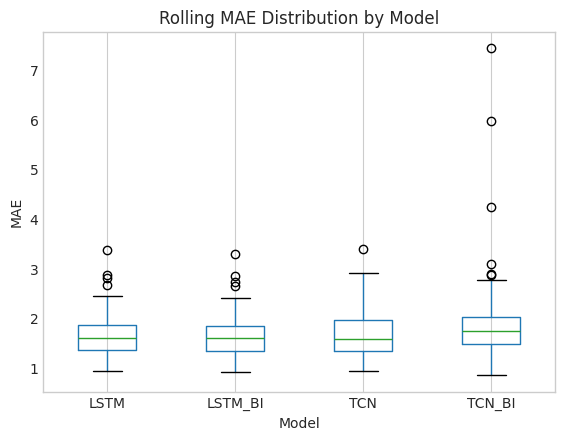

In [ ]:
plt.figure(figsize=(12, 5))
rolling_all.boxplot(column="mae", by="model_name")
plt.title("Rolling MAE Distribution by Model")
plt.suptitle("")
plt.xlabel("Model")
plt.ylabel("MAE")
plt.grid(axis="y")
plt.show()

<Figure size 1200x500 with 0 Axes>

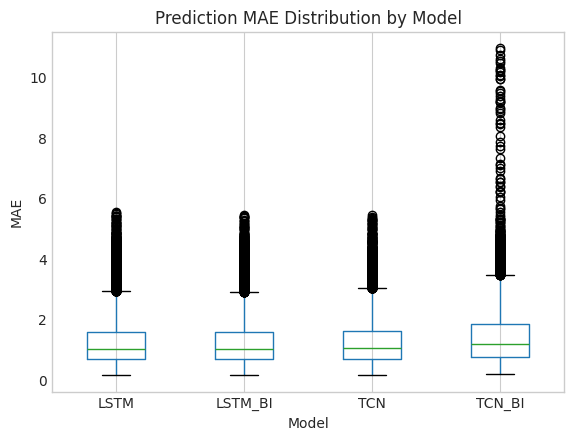

In [ ]:
plt.figure(figsize=(12, 5))
prediction_all.boxplot(column="mae", by="model_name")
plt.title("Prediction MAE Distribution by Model")
plt.suptitle("")
plt.xlabel("Model")
plt.ylabel("MAE")
plt.grid(axis="y")
plt.show()

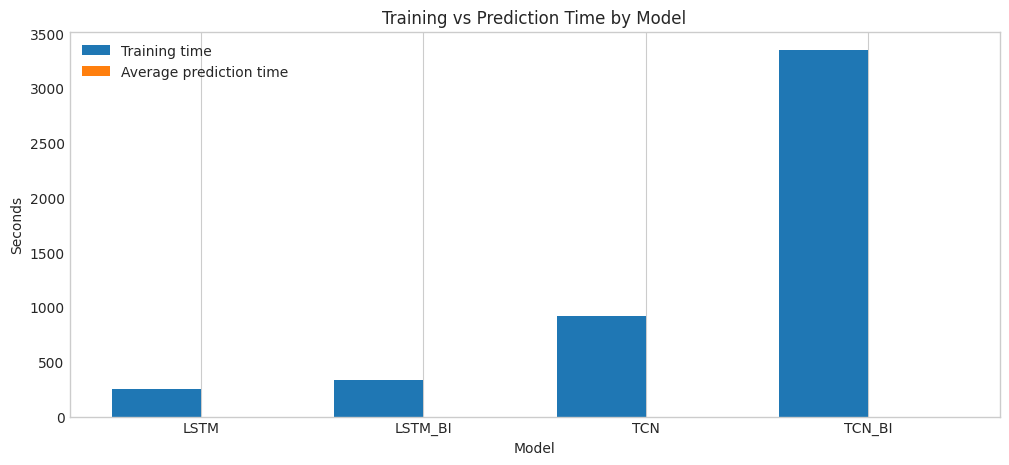

In [ ]:
plt.figure(figsize=(12, 5))
model_names = list(result_models.keys())
training_times = [result_models[model_name]["training_time"] for model_name in model_names]
prediction_times = [prediction_all.loc[prediction_all["model_name"] == model_name, "prediction_time_sec"].mean() for model_name in model_names]
positions = range(len(model_names))
plt.bar([position - 0.2 for position in positions], training_times, width=0.4, label="Training time")
plt.bar([position + 0.2 for position in positions], prediction_times, width=0.4, label="Average prediction time")
plt.xticks(list(positions), model_names)
plt.title("Training vs Prediction Time by Model")
plt.xlabel("Model")
plt.ylabel("Seconds")
plt.legend()
plt.grid(axis="y")
plt.show()

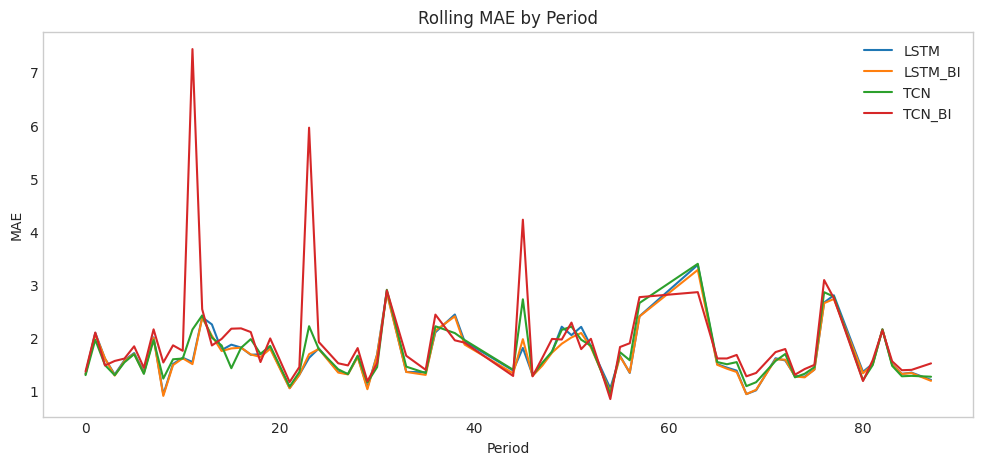

In [ ]:
plt.figure(figsize=(12, 5))
for model_name, model_frame in rolling_all.groupby("model_name"):
    model_series = model_frame.sort_values("period")
    plt.plot(model_series["period"], model_series["mae"], label=model_name)
plt.title("Rolling MAE by Period")
plt.xlabel("Period")
plt.ylabel("MAE")
plt.legend()
plt.grid()
plt.show()

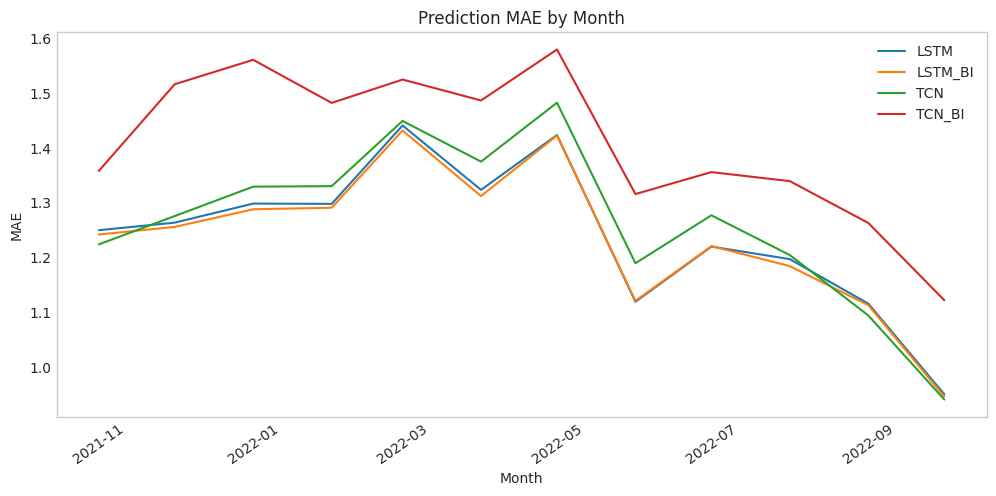

In [ ]:
plt.figure(figsize=(12, 5))
for model_name, model_frame in prediction_all.groupby("model_name"):
    monthly_frame = (
        model_frame.groupby("window_month")["mae"]
        .mean()
        .reset_index()
        .sort_values("window_month")
    )
    plt.plot(monthly_frame["window_month"].dt.to_timestamp(), monthly_frame["mae"], label=model_name)
plt.title("Prediction MAE by Month")
plt.xlabel("Month")
plt.ylabel("MAE")
plt.legend()
plt.xticks(rotation=35)
plt.grid()
plt.show()

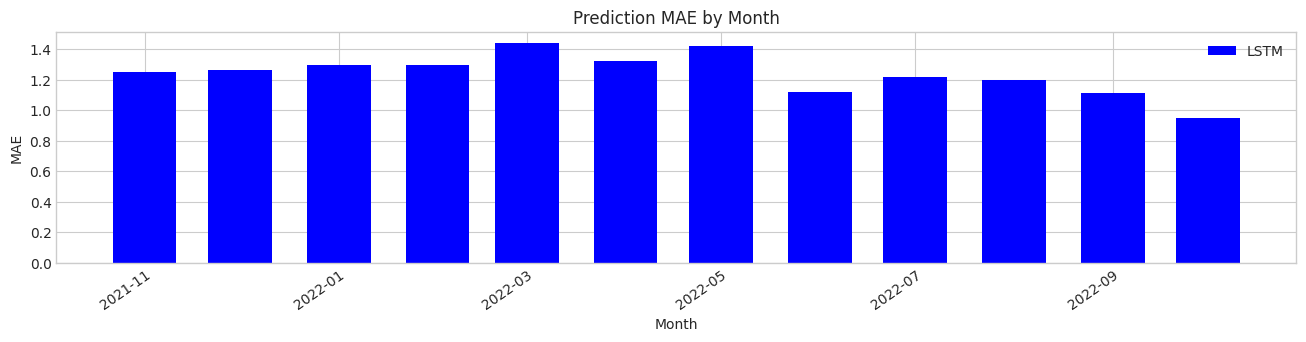

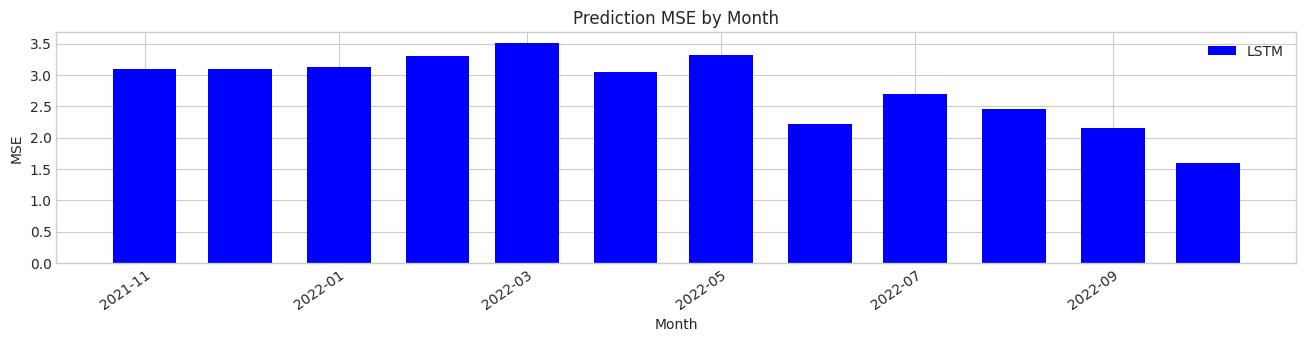

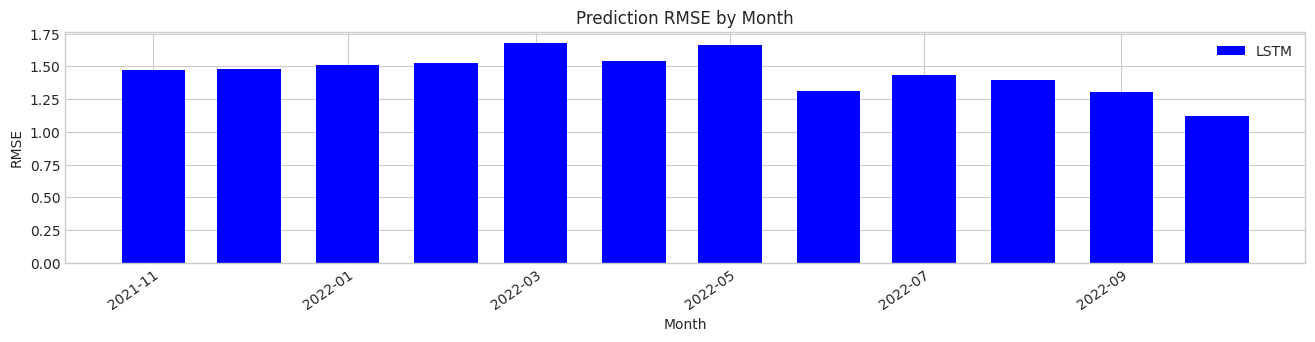

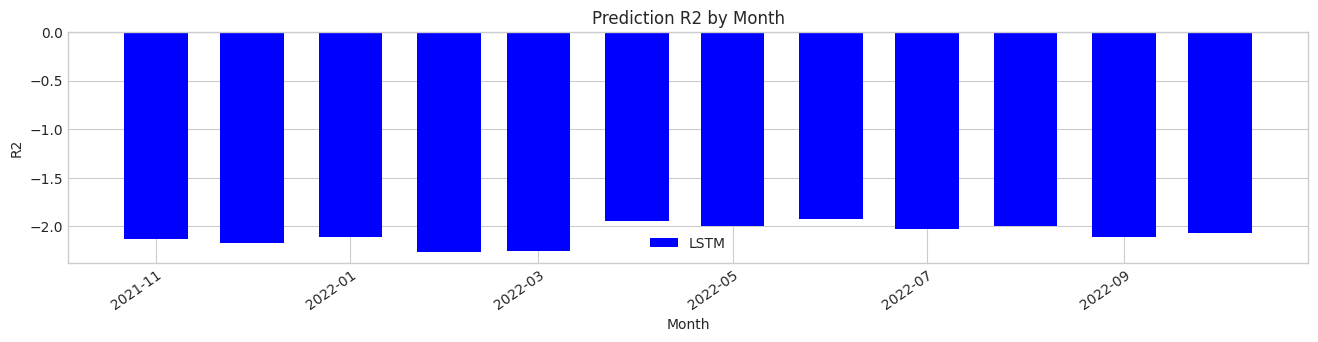

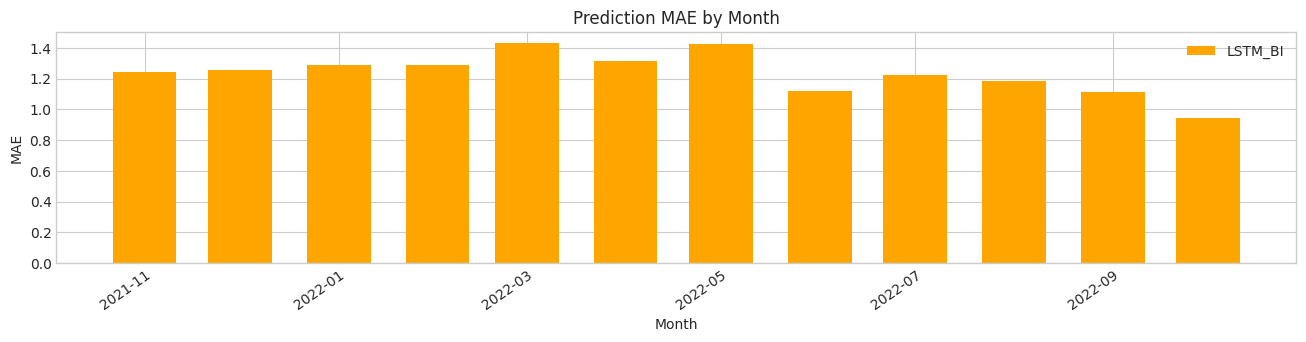

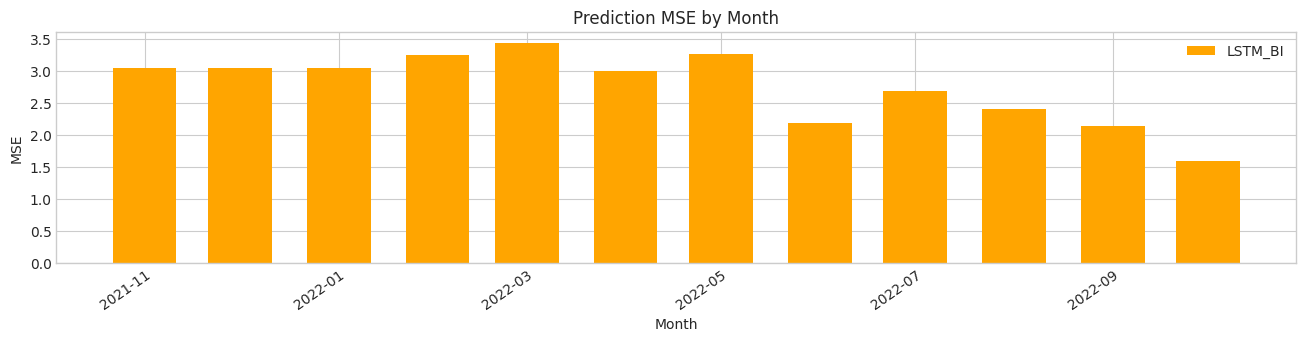

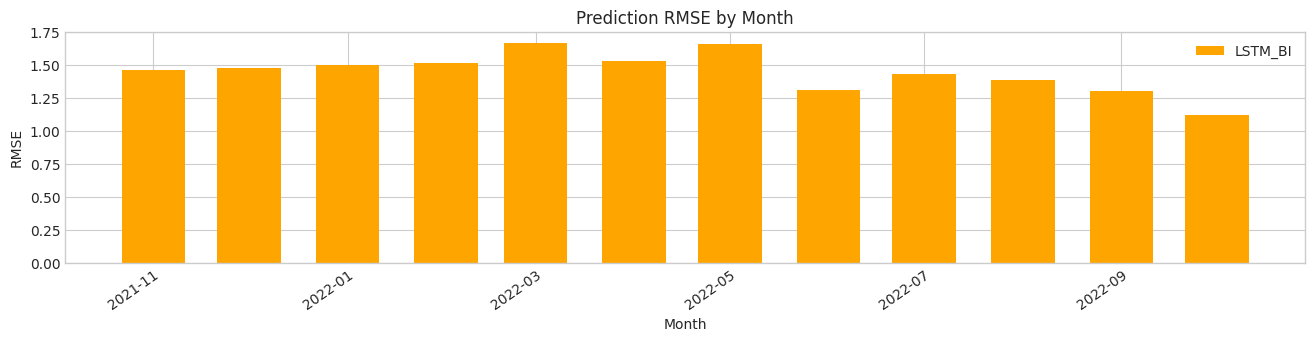

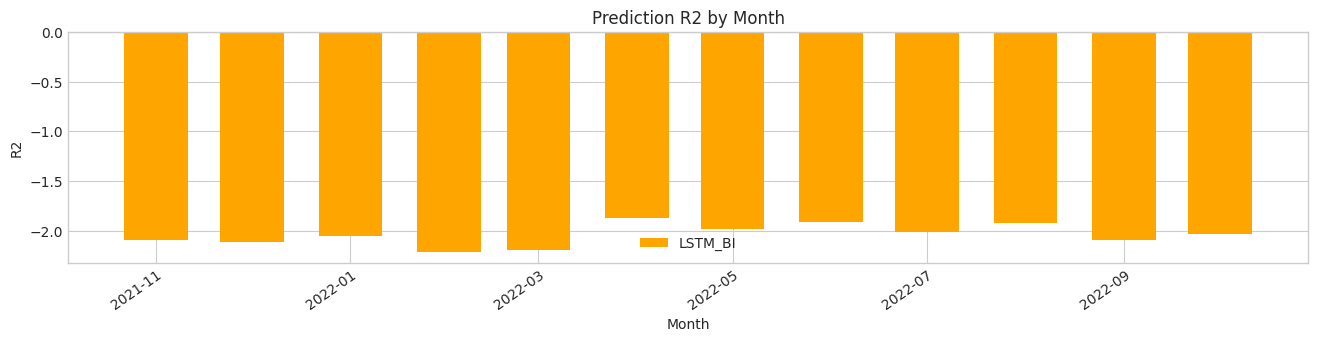

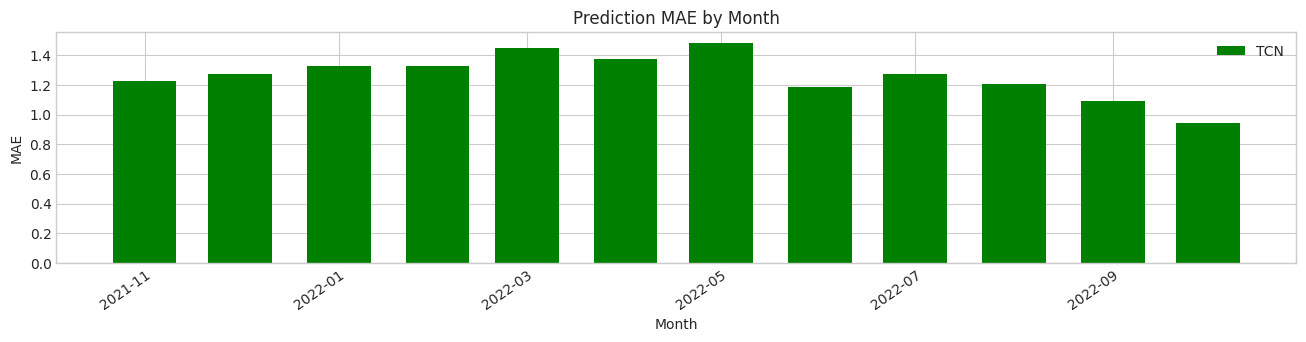

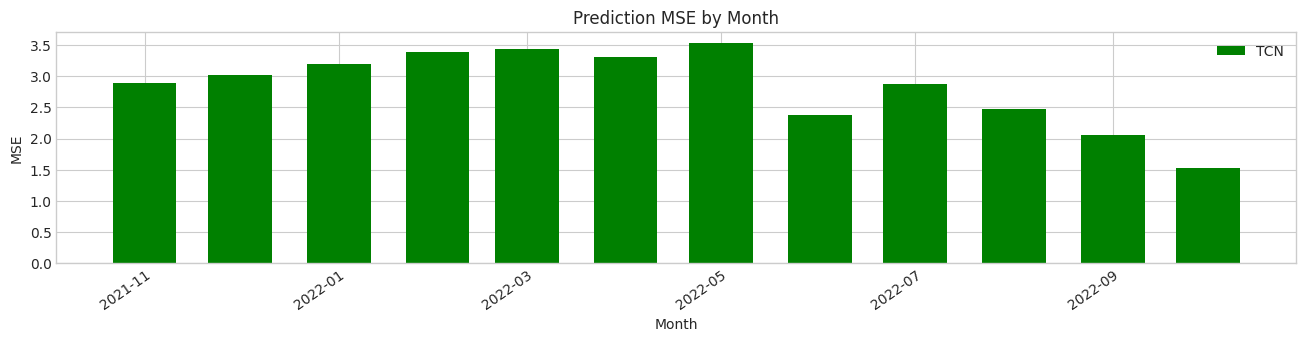

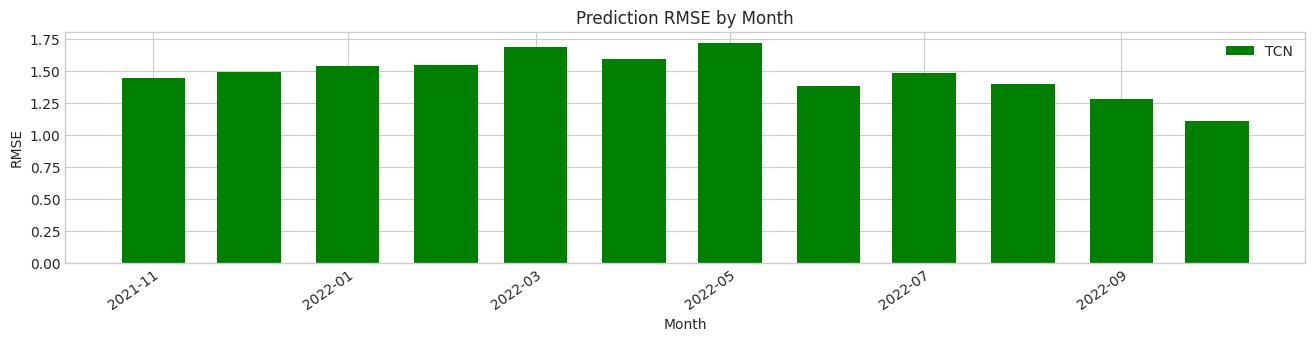

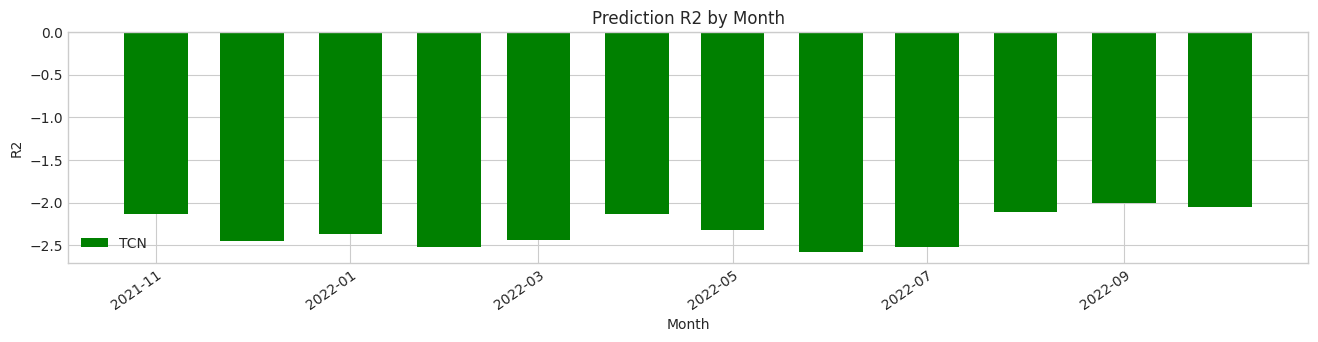

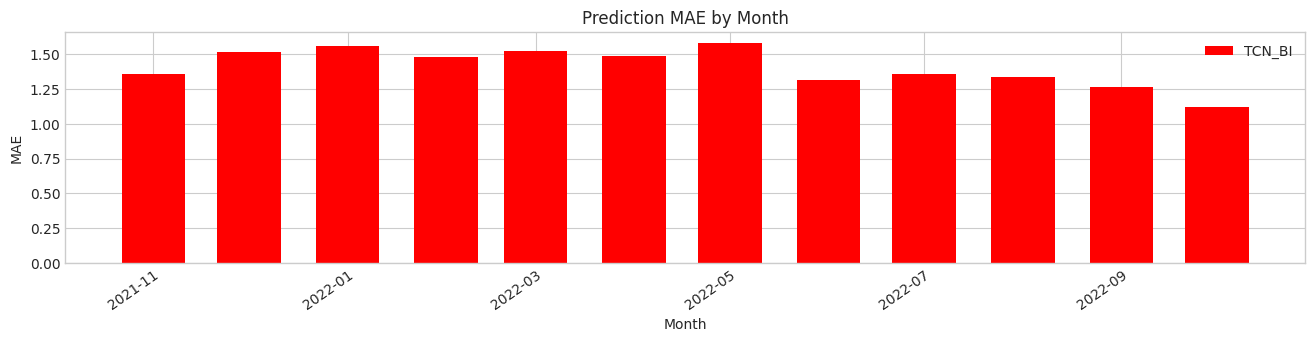

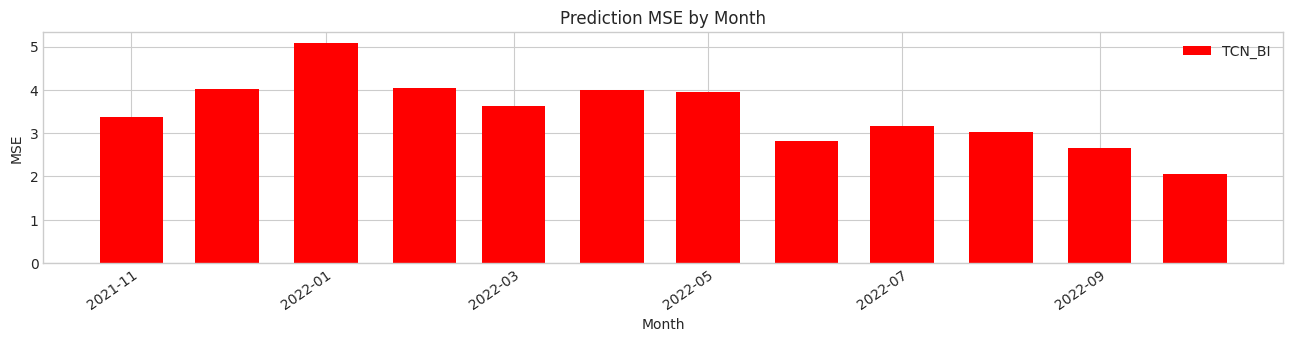

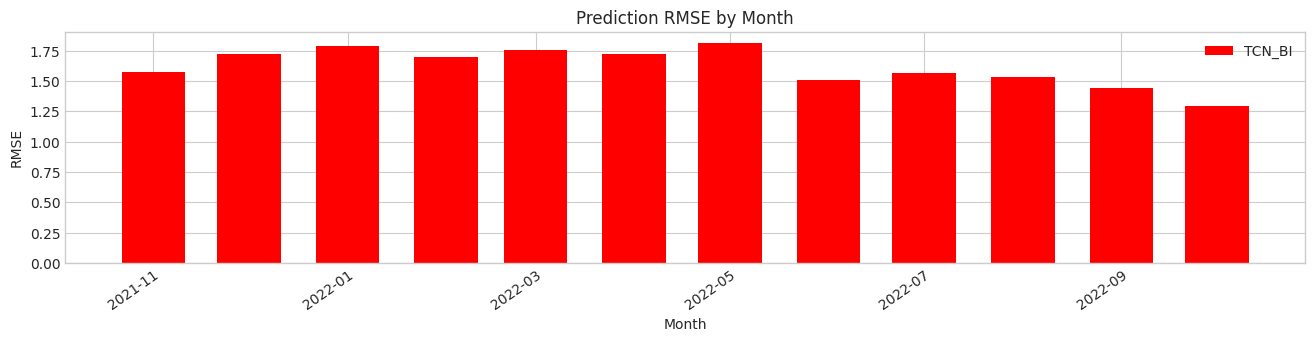

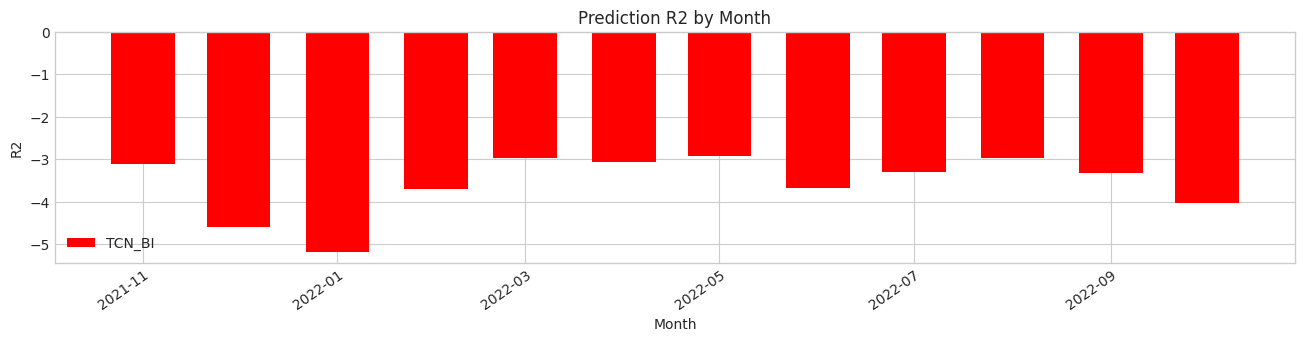

In [ ]:
model_colors = {
    "LSTM": "blue",
    "LSTM_BI": "orange",
    "TCN": "green",
    "TCN_BI": "red"
}
for model_name, model_frame in prediction_all.groupby("model_name"):
    for metric in ["mae", "mse", "rmse", "r2"]:
        plt.figure(figsize=(16, 3))
        monthly_frame = (
            model_frame.groupby("window_month") [metric]
            .mean()
            .reset_index()
            .sort_values("window_month")
        )
        plt.bar(monthly_frame["window_month"].dt.to_timestamp(), monthly_frame[metric], label=model_name, width=20, color=model_colors.get(model_name, "gray"))
        plt.title(f"Prediction {metric.upper()} by Month")
        plt.xlabel("Month")
        plt.ylabel(metric.upper())
        plt.legend()
        plt.xticks(rotation=35, ha='right', rotation_mode='anchor')
        plt.grid(visible=True, axis="y")
        plt.show()

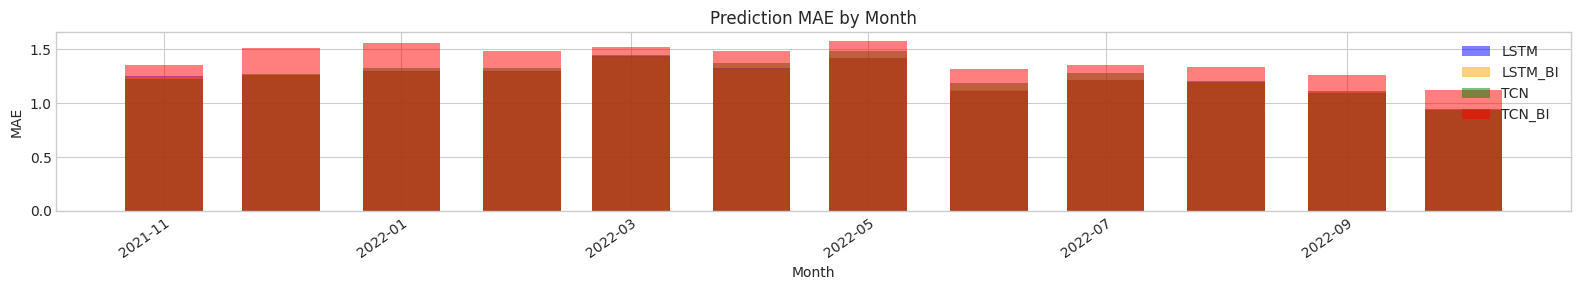

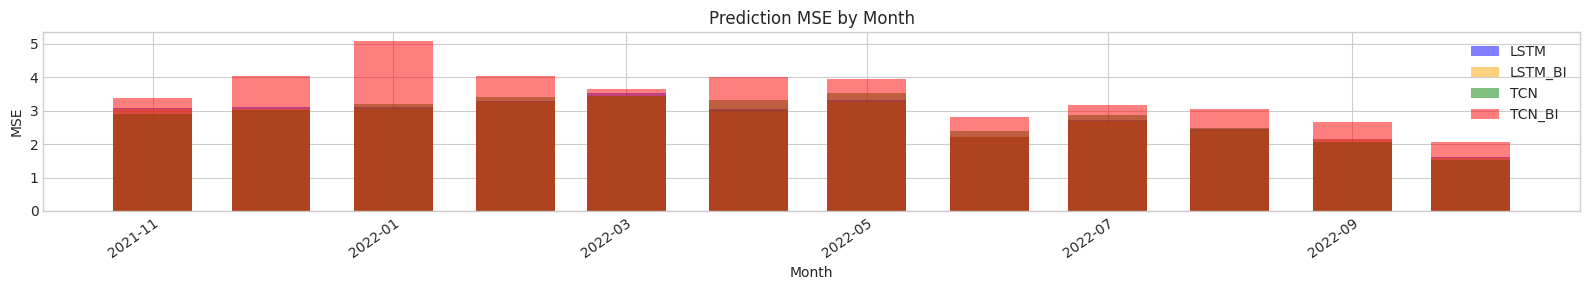

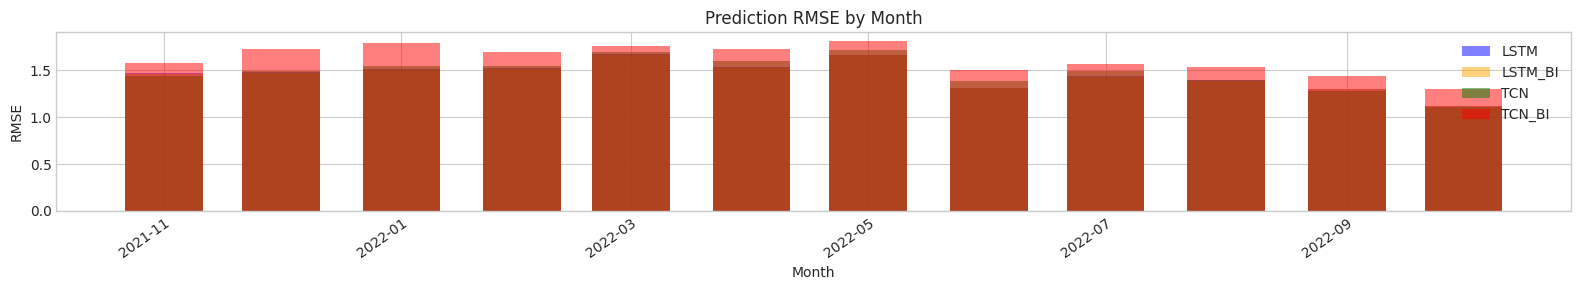

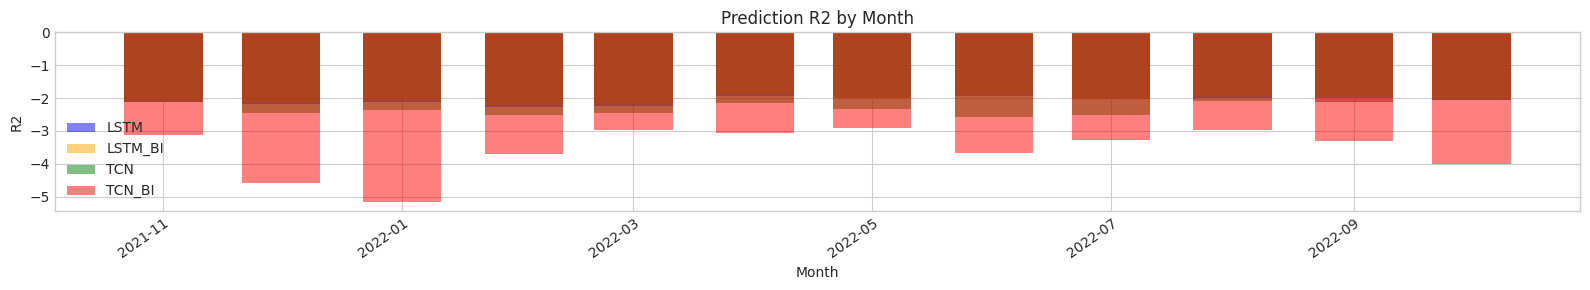

In [ ]:
model_colors = {
    "LSTM": "blue",
    "LSTM_BI": "orange",
    "TCN": "green",
    "TCN_BI": "red"
}
for metric in ["mae", "mse", "rmse", "r2"]:
    plt.figure(figsize=(16, 3))

    for model_name, model_frame in prediction_all.groupby("model_name"):
        
        monthly_frame = (
                model_frame.groupby("window_month") [metric]
                .mean()
                .reset_index()
                .sort_values("window_month")
        )
        plt.bar(monthly_frame["window_month"].dt.to_timestamp(), monthly_frame[metric], label=model_name, width=20, color=model_colors.get(model_name, "gray"), alpha=0.5)
    plt.title(f"Prediction {metric.upper()} by Month")
    plt.xlabel("Month")
    plt.ylabel(metric.upper())
    plt.legend()
    plt.xticks(rotation=35, ha='right', rotation_mode='anchor')
    plt.grid(visible=True, axis="y")
    plt.tight_layout()
    plt.show()